In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd

In [8]:
adata = sdata["square_032um"]
sc.pp.calculate_qc_metrics(adata, inplace=True)

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

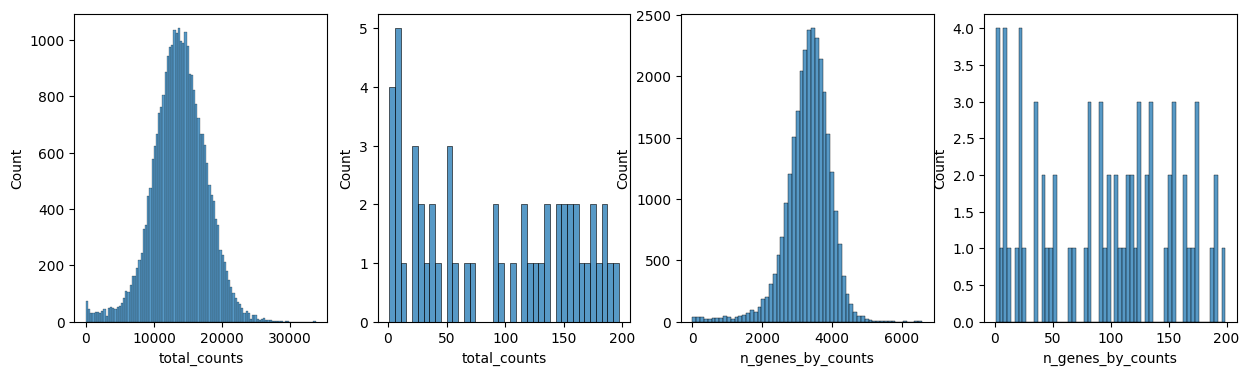

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < 200],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 200],
    kde=False,
    bins=60,
    ax=axs[3],
)

In [ ]:
adata.var_names_make_unique()
adata.write_h5ad("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_032um.h5ad")

In [13]:
adata.obs["cell_ID"]

cells
8686_Visium_HD_Liver_square_032um_labels_e00fd327      8686
8687_Visium_HD_Liver_square_032um_labels_e00fd327      8687
8688_Visium_HD_Liver_square_032um_labels_e00fd327      8688
8689_Visium_HD_Liver_square_032um_labels_e00fd327      8689
8690_Visium_HD_Liver_square_032um_labels_e00fd327      8690
                                                      ...  
73428_Visium_HD_Liver_square_032um_labels_e00fd327    73428
73429_Visium_HD_Liver_square_032um_labels_e00fd327    73429
73430_Visium_HD_Liver_square_032um_labels_e00fd327    73430
73431_Visium_HD_Liver_square_032um_labels_e00fd327    73431
73432_Visium_HD_Liver_square_032um_labels_e00fd327    73432
Name: cell_ID, Length: 29166, dtype: uint32

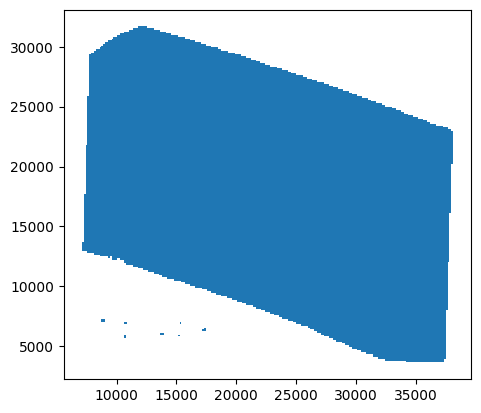

In [27]:
# Filter sdata["Visium_HD_Liver_square_032um"] to only include cells in adata.obs["cell_ID"]
cells_ids_in_tissue = sdata["Visium_HD_Liver_square_032um"].loc[adata.obs["cell_ID"]]
cells_ids_in_tissue.plot()

# Export the point object in two columns, x and y
df = pd.DataFrame({
    "x": cells_ids_in_tissue.centroid.x,
    "y": cells_ids_in_tissue.centroid.y
})

In [29]:
df.to_csv("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_032um_centroids.csv", index=True, header=True)

In [2]:
import scanpy as sc

adata = sc.read_h5ad("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_032um.h5ad")

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
adata